# Boundary Suppression Recovery Analysis

This notebook compares the degree of insulation recovery across four experimental
conditions:

- **Control** — Ledidi-optimized suppressed boundaries, edits allowed anywhere in the
  central bin (no CTCF masking)
- **Experimental** — Ledidi-optimized suppressed boundaries, edits restricted to
  non-CTCF positions in the central bin
- **B-box shuffling** — experimental sequences with B-box motifs shuffled in the
  central bin; tests whether intact Pol III Box B elements are required for suppression
- **SINE B2 insertion (n = 1, 2, 3)** — consensus SINE B2 (B2_Mm2) elements inserted
  into the central bin of original (non-optimized) sequences; tests whether SINE B2
  dosage is sufficient to suppress boundaries de novo

All scores are scaled relative to the original boundary strength so that:
- **0** = no change from the original boundary
- **1** = full recovery to flat-region level

## 1. Imports & paths

In [1]:
import os
import sys

import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))
from utils.df_utils import simple_load_results

BASE_DIR  = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundary_suppression/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIRS         = ["results"]
CONTROL_RESULT_DIRS = ["control"]
FOLDS               = range(8)

BBOX_TSV   = BASE_DIR / "successful_Bbox_shuffling_results.tsv"
SINEB2_TSV = BASE_DIR / "sine_b2_insertion_results.tsv"

## 2. Load data

In [2]:
df         = simple_load_results(RESULT_DIRS,         BASE_DIR, FOLDS, "suppression_results.tsv")
control_df = simple_load_results(CONTROL_RESULT_DIRS, BASE_DIR, FOLDS, "suppression_results.tsv")

df["insul_score_diff"]     = df["insul_score_edited"] - df["insul_score_orig"]
df["optimization_success"] = df["insul_score_diff"] > 0

print(f"Loaded {len(df)} optimized windows across {df['fold'].nunique()} folds")
print(f"Loaded {len(control_df)} control windows across {control_df['fold'].nunique()} folds")
print(f"\nSuccessful optimizations: {df['optimization_success'].sum()} / {len(df)} "
      f"({100 * df['optimization_success'].mean():.1f}%)")

Loaded 323 optimized windows across 8 folds
Loaded 323 control windows across 8 folds

Successful optimizations: 323 / 323 (100.0%)


## 3. Load B-box shuffling & SINE B2 insertion results

In [3]:
bbox_df   = pd.read_csv(BBOX_TSV, sep="\t")
bbox_df   = bbox_df.drop(columns=["insul_score_edited"]).rename(columns={"insul_score_bbox_shuffled": "insul_score_edited"})
sineb2_df = pd.read_csv(SINEB2_TSV, sep="\t")
sineb2_df = sineb2_df.rename(columns={
    "URQ_orig": "insul_score_orig",
    "URQ_sine": "insul_score_edited",
})

print(f"B-box shuffling : {len(bbox_df)} windows")
print(f"SINE B2 insertions : {len(sineb2_df)} rows")

B-box shuffling : 323 windows
SINE B2 insertions : 969 rows


## 4. Scaling

Scores are normalised so that the original boundary strength anchors 0 and the
flat-region level anchors 1.

In [4]:
def get_scaled_diff(dataframe):
    """
    Scale the difference by the original boundary strength.
    Returns: (insul_score_edited - insul_score_orig) / (0 - insul_score_orig)
    """
    diff = dataframe["insul_score_edited"] - dataframe["insul_score_orig"]
    return diff / (-dataframe["insul_score_orig"])

In [5]:
data_to_plot = [
    get_scaled_diff(control_df).dropna(),
    get_scaled_diff(df).dropna(),
    get_scaled_diff(bbox_df).dropna(),
    get_scaled_diff(sineb2_df[sineb2_df["n_insertions"] == 1]).dropna(),
    get_scaled_diff(sineb2_df[sineb2_df["n_insertions"] == 2]).dropna(),
    get_scaled_diff(sineb2_df[sineb2_df["n_insertions"] == 3]).dropna(),
]

labels = [
    "Control (no CTCF mask)",
    "Experimental (CTCF masked)",
    "B-box (shuffled)",
    "SINE B2 (n=1)",
    "SINE B2 (n=2)",
    "SINE B2 (n=3)",
]

for label, d in zip(labels, data_to_plot):
    print(f"{label:30s}  n={len(d):4d}  median={d.median():+.3f}  mean={d.mean():+.3f}  std={d.std():.3f}")

Control (no CTCF mask)          n= 323  median=+0.897  mean=+0.851  std=1.335
Experimental (CTCF masked)      n= 323  median=+0.840  mean=+0.809  std=1.339
B-box (shuffled)                n= 323  median=+0.695  mean=+0.708  std=0.832
SINE B2 (n=1)                   n= 323  median=+0.007  mean=+0.043  std=0.521
SINE B2 (n=2)                   n= 323  median=+0.036  mean=+0.141  std=0.244
SINE B2 (n=3)                   n= 323  median=+0.094  mean=+0.142  std=1.207


## 5. Relative boundary suppression

Boxes show the distribution of relative suppression scores per condition.
The dashed green line marks full recovery to flat-region level (score = 1);
the dashed red line marks no change from the original boundary (score = 0).

/tmp/SLURM_3044630/ipykernel_187775/2867848456.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


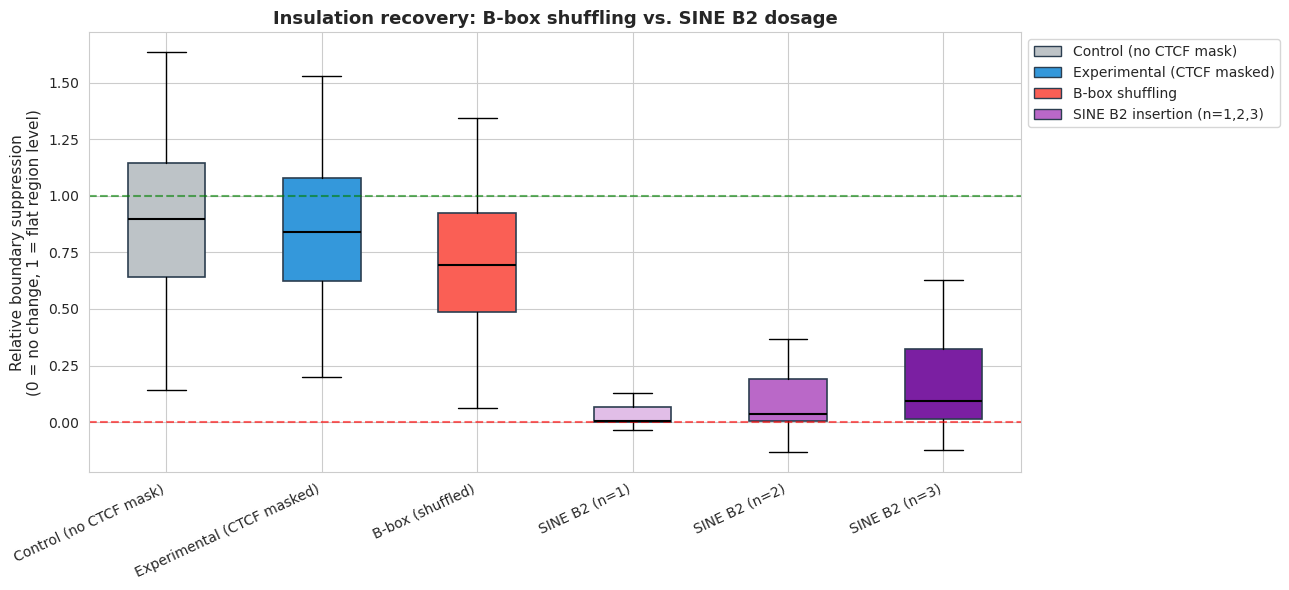

In [8]:
COLORS = [
    "#bdc3c7",  # Control         — grey
    "#3498db",  # Experimental    — blue
    "#FA5F55",  # B-box shuffled  — coral
    "#e1bee7",  # SINE B2 n=1     — light purple
    "#ba68c8",  # SINE B2 n=2     — medium purple
    "#7b1fa2",  # SINE B2 n=3     — deep purple
]

plt.figure(figsize=(13, 6))
sns.set_style("whitegrid")

bp = plt.boxplot(
    data_to_plot,
    labels=labels,
    patch_artist=True,
    showfliers=False,
    whis=1,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(linewidth=1.2),
)

for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_edgecolor("#2c3e50")

plt.axhline(y=1, color="green", linestyle="--", alpha=0.6, label="Flat region level")
plt.axhline(y=0, color="red",   linestyle="--", alpha=0.6, label="Boundary level")

legend_elements = [
    mpatches.Patch(facecolor="#bdc3c7", edgecolor="#2c3e50", label="Control (no CTCF mask)"),
    mpatches.Patch(facecolor="#3498db", edgecolor="#2c3e50", label="Experimental (CTCF masked)"),
    mpatches.Patch(facecolor="#FA5F55", edgecolor="#2c3e50", label="B-box shuffling"),
    mpatches.Patch(facecolor="#ba68c8", edgecolor="#2c3e50", label="SINE B2 insertion (n=1,2,3)"),
]

plt.ylabel("Relative boundary suppression\n(0 = no change, 1 = flat region level)", fontsize=11)
plt.title("Insulation recovery: B-box shuffling vs. SINE B2 dosage",
          fontsize=13, fontweight="bold")
plt.xticks(rotation=25, ha="right")
plt.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "boundary_suppression_insulation_comparisson.svg", format="svg", bbox_inches="tight")
plt.show()